In [2]:
# @title imports 
%load_ext autoreload
%autoreload 2
import os
import pickle
from typing import Set
# from jedi import settings
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse import data 
import pandas as pd 
import seaborn as sns
 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# import umap.plot as uplot
import sys  

# sys.path.append('C:/Users/Nishant Joshi/Downloads/Old_code/repo/single_cell_analysis/scripts')
sys.path.append(os.getcwd()+'/../scripts/')
from utils import *
from UMAP_utils import *
from plot_utils import *
from cluster_stability import *
from neuromod_utils import * 
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
savepath = 'G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/'
# savepath2 = 'G:/My Drive/Data For Publication/paper2/PNAS_revision/'

In [3]:
discarded_exps = ['xuan_151118_E1',
                  'xuan_15319_E1',
                  'xuan_20919_E2',
                  'xuan_27919_E1',
                  'xuan_27919_E2',
                  'xuan_27919_E3',
                  'NC_20717_E5' ,
                  'NC_25717_E2',
                  'payam_31019_E5',
                  'payam_101019_E5',
                  'NC_24717_E1',
                  'xuan_27319_E4',
                  'xuan_23119_E2',
                  'xuan_3419_E2',
                  'xuan_22319_E1',
                  'xuan_19319_E4',
                  'xuan_22319_E4',
                  'xuan_26319_E4']

In [4]:
# %matplotlib widget

ephys = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms.pkl")
ephys_with_mi = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms_with_MI.pkl")

# ephys = ephys[~ephys.exp_name.isin(discarded_exps)]
ephys_with_mi = ephys_with_mi[~ephys_with_mi.exp_name.isin(discarded_exps)]



data_ephys_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][ephys.columns[1:]]
data_ephys_FN_acsf = data_ephys_FN_acsf[data_ephys_FN_acsf.trialnr==0]

data_wave_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][['waveform','tau', 'exp_name', 'cond', 'trialnr']]
data_wave_FN_acsf=data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]
# data_wave_FN_acsf.drop_duplicates('exp_name')

# exps_with_double_trials = np.array(data_wave_FN_acsf.exp_name)[list(np.where(np.unique(data_wave_FN_acsf.exp_name,return_counts=True)[1]>1)[0])]
# data_wave_FN_acsf = data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]



In [5]:
acsf_temp, drug_temp = return_acsf_and_drug(ephys,cond=['d1'],joint=False,remove_duplicates=True,sample=None)

Reviewer comment: the use of two different frozen noise input types depending on neuron responsiveness (mentioned briefly in the limitations) is a potentially serious confound that is underplayed. If excitatory and inhibitory neurons systematically received different input statistics, then differences in FI between cell types are partially uninterpretable, since FI is input-statistic-dependent. The authors need to either demonstrate that results are robust across input type or explicitly partition the analysis by input type. 

## FI and FR across two input types

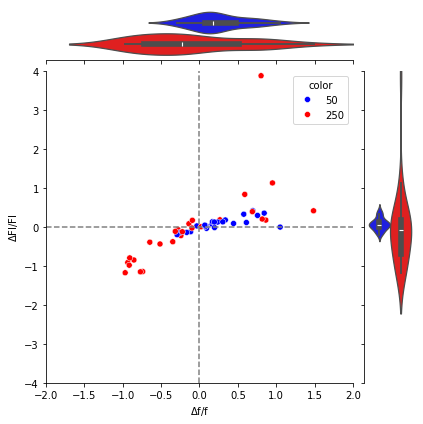

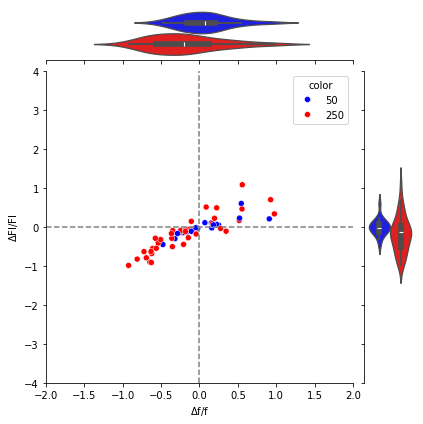

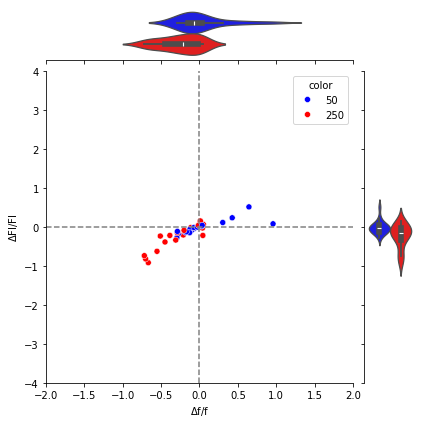

In [6]:
def plot_FI_vs_FR_input_based(data_acsf,data_drug,ax=None, plot=True, c = 'blue',x_lim = None, y_lim = None, save=False, savepath = None):
    ind_na = np.array(data_drug['FI'].isna())
    c_labels = []
    data_acsf = data_acsf[~ind_na]
    data_drug = data_drug[~ind_na]

    for i in data_acsf.tau:
        if i==250:
            c_labels.append('250')
        else:
            c_labels.append('50')

    c = c_labels
    delta_fi = (np.array(data_drug['FI']) - np.array(data_acsf['FI']))/np.array(data_acsf['FI'])
    delta_fr = (np.array(data_drug['fr']) - np.array(data_acsf['fr']))/np.array(data_acsf['fr'])
    df_temp = pd.DataFrame({'$\Delta$f/f':np.float32(delta_fr),
                                '$\Delta$FI/FI':np.float32(delta_fi),
                                'color':c})

    df_temp = df_temp[(df_temp['$\Delta$FI/FI']>=y_lim[0]) &(df_temp['$\Delta$FI/FI']<=y_lim[1])]
    df_temp = df_temp[(df_temp['$\Delta$f/f']>=x_lim[0]) &(df_temp['$\Delta$f/f']<=x_lim[1])]

    if plot:
        if ax is None:

            g = sns.JointGrid(data=df_temp, x="$\Delta$f/f", y="$\Delta$FI/FI",hue='color',palette=['blue','red'])
            g.plot(sns.scatterplot, sns.violinplot)
            g.ax_joint.axhline(y=0, color='gray', linestyle='--')  # Horizontal line at y=16
            g.ax_joint.axvline(x=0, color='gray', linestyle='--')  # Horizontal line at y=16

            if x_lim !=None and y_lim !=None: 
                g.ax_joint.set_xlim(x_lim)
                g.ax_joint.set_ylim(y_lim)
            # plt.legend(['inh','exc'])

            plt.xlabel('$\Delta$fr/fr')
            plt.ylabel('$\Delta$FI/FI')

            if save:
                plt.savefig(savepath,dpi=200)
            plt.show()
        else:
            ax.scatter(delta_fr[~ind_na], delta_fi[~ind_na],c=c) 

    return df_temp

for cond in ['d1','d2','m1-ago']:
    # cond  = 'm1-ago'
    data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=[cond],joint=False)
    plot_FI_vs_FR_input_based(data_acsf,data_drug,x_lim=[-2,2],y_lim=[-4,4],save=True,
                            savepath=savepath+cond+'.pdf')
    # plot_FI_vs_FR(data_acsf,data_drug,save=False,savepath=savepath2+cond+'.pdf')



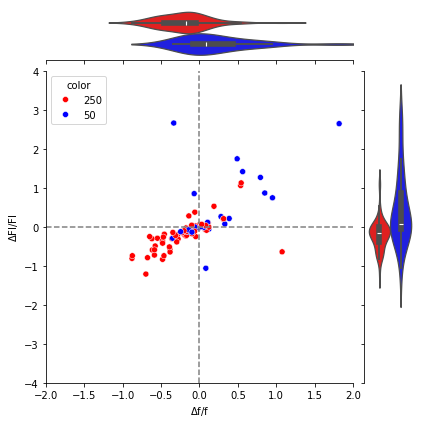

In [7]:
repeated_acsf = ephys[ephys.cond=='acsf']
idx = np.where(np.unique(repeated_acsf.exp_name,return_counts=True)[1]>1)[0]
names = np.unique(repeated_acsf.exp_name,return_counts=True)[0][idx]

acsf_with_2_trials = list(set(np.array(repeated_acsf.exp_name)[idx]))
repeated_acsf_filtered = repeated_acsf[repeated_acsf.exp_name.isin(names)]
exps,counts = np.unique(repeated_acsf_filtered.exp_name,return_counts=True)
delta_FI = []
delta_fr = []
ei = []
for exp in exps:
    df = repeated_acsf_filtered[repeated_acsf_filtered.exp_name==exp]
    if np.array(df.tau)[0] ==250:
        ei.append('250')
    else:
        ei.append('50')

    FI1 = df[df.trialnr == 0 ]['FI']
    FI2 = df[df.trialnr == 1 ]['FI']
    delta_FI.append((FI2.to_numpy()-FI1.to_numpy())/FI1.to_numpy())

    Fr1 = df[df.trialnr == 0 ]['fr']
    Fr2 = df[df.trialnr == 1 ]['fr']
    delta_fr.append((Fr2.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())


data_frame  = pd.DataFrame({'$\Delta$f/f'   :np.float32(np.hstack(delta_fr)),
                            '$\Delta$FI/FI' :np.float32(np.hstack(delta_FI)),
                            'color':ei})
ylim = [-4,4]
xlim = [-2,2]
data_frame = data_frame[(data_frame['$\Delta$FI/FI']<=ylim[1]) & (data_frame['$\Delta$FI/FI']>ylim[0])]
data_frame = data_frame[(data_frame['$\Delta$f/f']<=xlim[1]) & (data_frame['$\Delta$f/f']>xlim[0])]


g = sns.JointGrid(data=data_frame, x="$\Delta$f/f", y="$\Delta$FI/FI",hue='color',palette=['red','blue'])
g.plot(sns.scatterplot, sns.violinplot)
g.ax_joint.axhline(y=0, color='gray', linestyle='--')  # Horizontal line at y=16
g.ax_joint.axvline(x=0, color='gray', linestyle='--')  # Horizontal line at y=16
g.ax_joint.set_xlim(xlim)
g.ax_joint.set_ylim(ylim)
plt.savefig(savepath+'acsf'+'.pdf',dpi=200)
plt.show()

In [8]:
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['d1'],joint=False)
d1_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['d2'],joint=False)
d2_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['m1-ago'],joint=False)
m1_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')


### Cell-type difference in FI

In [9]:
from scipy import stats
inh_data = d1_diff[d1_diff.color=='50']
exc_data = d1_diff[d1_diff.color=='250']
print('D1')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))

inh_data = d2_diff[d2_diff.color=='50']
exc_data = d2_diff[d2_diff.color=='250']
print('D2')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))


inh_data = m1_diff[m1_diff.color=='50']
exc_data = m1_diff[m1_diff.color=='250']
print('M1')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))


print('acsf-acsf')
inh_data = data_frame[data_frame.color=='50']
exc_data = data_frame[data_frame.color=='250']

print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))
# exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)


D1
Ttest_indResult(statistic=-2.1877446371569187, pvalue=0.03369596058855785) -0.6381250870690611
D2
Ttest_indResult(statistic=-1.5950742747543802, pvalue=0.1163244233978533) -0.452692281735004
M1
Ttest_indResult(statistic=-2.7761873331200397, pvalue=0.008489634380959388) -0.9012329080228657
acsf-acsf
Ttest_indResult(statistic=-4.612144694799919, pvalue=1.432163758788396e-05) -1.1458069407323892


### Cell type difference in Firing rate 

In [10]:
from scipy import stats
inh_data = d1_diff[d1_diff.color=='50']
exc_data = d1_diff[d1_diff.color=='250']
print('D1')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))

inh_data = d2_diff[d2_diff.color=='50']
exc_data = d2_diff[d2_diff.color=='250']
print('D2')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))


inh_data = m1_diff[m1_diff.color=='50']
exc_data = m1_diff[m1_diff.color=='250']
print('M1')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))


print('acsf-acsf')
inh_data = data_frame[data_frame.color=='50']
exc_data = data_frame[data_frame.color=='250']

print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))
# exc_data['$$\Delta$f/f'].to_numpy(dtype=np.float32)


D1
Ttest_indResult(statistic=-2.4564764163929875, pvalue=0.017779909066199393) -0.7165955044282073
D2
Ttest_indResult(statistic=-2.0580811537289057, pvalue=0.04424772491935502) -0.5849167348709308
M1
Ttest_indResult(statistic=-3.165776300013601, pvalue=0.003043993341474742) -1.0287213419357373
acsf-acsf
Ttest_indResult(statistic=-4.486221004667964, pvalue=2.3110418278060785e-05) -1.1109038828975446


Reviewer comment: The baseline drift in excitatory neurons across repeated control trials (the significant decrease in FI and FR even without drug, Cohen's d around -0.6 to -0.9) is flagged but then dismissed. This is actually a non-trivial concern: if excitatory neurons are inherently less stable across the recording epoch, then the drug effects - particularly for D2 where the authors themselves note the shift is of similar magnitude to baseline variability - may be confounded by recording-related drift rather than receptor activation. A more rigorous analysis would model trial order as a covariate or demonstrate that drift is statistically dissociable from drug effects.

## Drift vs Drug trial comparison

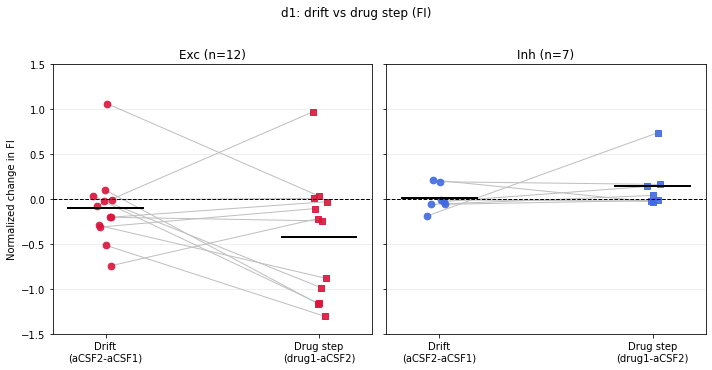

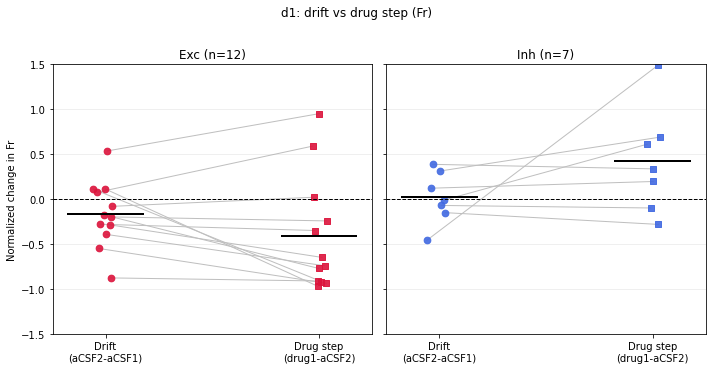

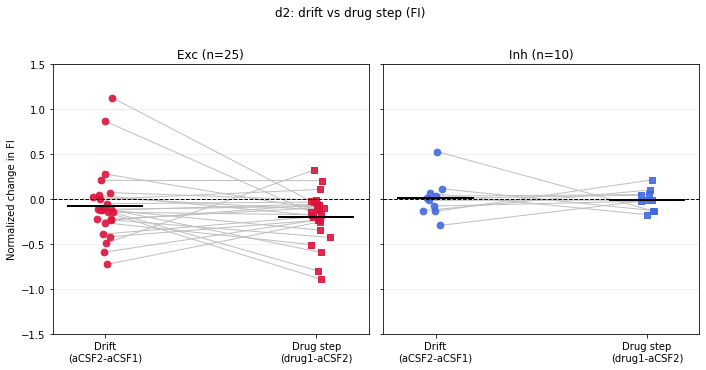

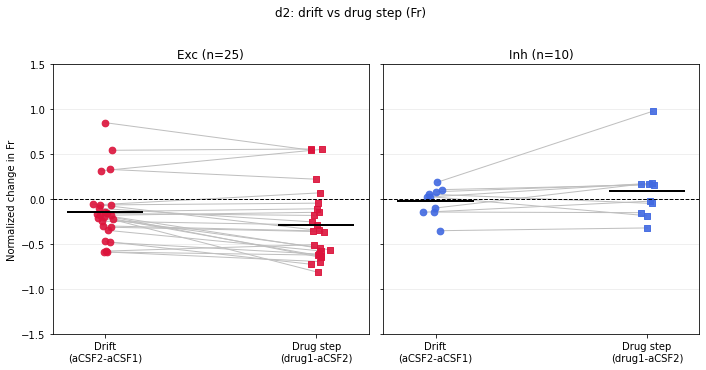

In [18]:

def paired_drift_plot(orig_df, receptor="d1", metric_label="FI", savepath=savepath,save=True):
    repeated_acsf = orig_df[orig_df.cond=='acsf']
    cond = receptor
    idx = np.where(np.unique(repeated_acsf.exp_name,return_counts=True)[1]>1)[0]
    names = np.unique(repeated_acsf.exp_name,return_counts=True)[0][idx]
    acsf_with_2_trials = list(set(np.array(repeated_acsf.exp_name)[idx]))
    repeated_acsf_filtered = repeated_acsf[repeated_acsf.exp_name.isin(names)]

    exps_with_repeated_acsf = repeated_acsf_filtered.exp_name.unique()
    drug_repeated = orig_df[orig_df.exp_name.isin(exps_with_repeated_acsf) ]
    drug_repeated_exps = drug_repeated[drug_repeated.cond==cond].exp_name.unique()
    drug_with_repeated_acsf = orig_df[orig_df.exp_name.isin(drug_repeated_exps)]

    exps,counts = np.unique(drug_with_repeated_acsf.exp_name,return_counts=True)
    delta_FI_repeated = []
    delta_FI_drug = []
    delta_fr_repeated = []
    delta_fr_drug = []

    ei = []

    for exp in exps:
        df = drug_with_repeated_acsf[drug_with_repeated_acsf.exp_name==exp]
        if np.array(df.ei_labels)[0] ==1.0:
            ei.append('Exc')
        else:
            ei.append('Inh')
        drug_idx = np.where(np.array(df.cond)==cond)[0][0]

        FI1 = df[df.trialnr == 0 ]['FI']
        FI2 = df[df.trialnr == 1 ]['FI']
        drug_data_FI = df[df.trialnr == drug_idx ]['FI']
        delta_FI_repeated.append((FI2.to_numpy()-FI1.to_numpy())/FI1.to_numpy())
        delta_FI_drug.append((drug_data_FI.to_numpy()-FI2.to_numpy())/FI2.to_numpy())

        Fr1 = df[df.trialnr == 0 ]['fr']
        Fr2 = df[df.trialnr == 1 ]['fr']
        drug_data_FR = df[df.trialnr == drug_idx ]['fr']

        delta_fr_repeated.append((Fr2.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())
        delta_fr_drug.append((drug_data_FR.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())


    data_frame  = pd.DataFrame({'$\Delta$f/f_repeated'   :np.float32(np.hstack(delta_fr_repeated)),
                                '$\Delta$FI/FI_repeated' :np.float32(np.hstack(delta_FI_repeated)),
                                '$\Delta$f/f_drug' :np.float32(np.hstack(delta_fr_drug)),
                                '$\Delta$FI/FI_drug' :np.float32(np.hstack(delta_FI_drug)),
                                'exp_name':np.hstack([np.repeat(exps[i],len(delta_fr_repeated[i])) for i in range(len(exps))]),
                                'color':ei})

    ylim = [-4,4]
    xlim = [-2,2]
    data_frame = data_frame[(data_frame['$\Delta$FI/FI_repeated']<=ylim[1]) & (data_frame['$\Delta$FI/FI_repeated']>ylim[0])]
    data_frame = data_frame[(data_frame['$\Delta$f/f_repeated']<=xlim[1]) & (data_frame['$\Delta$f/f_repeated']>xlim[0])]
    data_frame = data_frame[(data_frame['$\Delta$FI/FI_drug']<=ylim[1]) & (data_frame['$\Delta$FI/FI_drug']>ylim[0])]
    data_frame = data_frame[(data_frame['$\Delta$f/f_drug']<=xlim[1]) & (data_frame['$\Delta$f/f_drug']>xlim[0])]

    df = data_frame.copy()
    # sub = df[df["cond"] == receptor].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    colors = {"Exc": "crimson", "Inh": "royalblue"}

    for ax, cell_type in zip(axes, ["Exc", "Inh"]):
        d = df[df["color"] == cell_type].copy().reset_index(drop=True)

        if len(d) == 0:
            ax.set_title(f"{cell_type}: no data")
            continue

        x1, x2 = 0, 1

        rng = np.random.default_rng(42)
        jitter1 = rng.normal(0, 0.03, len(d))
        jitter2 = rng.normal(0, 0.03, len(d))
        if metric_label == "FI":
             y1 = "$\Delta$FI/FI_repeated"
             y2 = "$\Delta$FI/FI_drug"  
        else:
             y1 = "$\Delta$f/f_repeated"
             y2 = "$\Delta$f/f_drug"          
        for i, row in d.iterrows():
            ax.plot(
                [x1 + jitter1[i], x2 + jitter2[i]],
                [row[y1], row[y2]],
                color="0.75",
                linewidth=1,
                zorder=1
            )

        ax.scatter(
            np.full(len(d), x1) + jitter1,
            d[y1],
            color=colors[cell_type],
            s=45,
            alpha=0.9,
            label="drift",
            zorder=2
        )

        ax.scatter(
            np.full(len(d), x2) + jitter2,
            d[y2],
            color=colors[cell_type],
            s=45,
            alpha=0.9,
            marker="s",
            label="drug step",
            zorder=2
        )

        mean_drift = d[y1].mean()
        mean_drug = d[y2].mean()

        ax.hlines(mean_drift, x1 - 0.18, x1 + 0.18, color="black", linewidth=2)
        ax.hlines(mean_drug, x2 - 0.18, x2 + 0.18, color="black", linewidth=2)

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xticks([x1, x2])
        ax.set_xticklabels(["Drift\n(aCSF2-aCSF1)", "Drug step\n(drug1-aCSF2)"])
        ax.set_title(f"{cell_type} (n={len(d)})")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(f"{cond}: drift vs drug step ({metric_label})", y=1.02)
    axes[0].set_ylabel(f"Normalized change in {metric_label}")
    plt.tight_layout()
    plt.ylim(-1.5, 1.5)
    if save:
        plt.savefig(savepath+f'{cond}_paired_drift_{metric_label}.pdf', dpi=200)    
    plt.show()
    return data_frame


df_d1_fi = paired_drift_plot(ephys, receptor='d1', metric_label="FI",savepath=savepath,save=True)
df_d1_fr = paired_drift_plot(ephys, receptor='d1', metric_label="Fr",savepath=savepath,save=True)

df_d2_fi = paired_drift_plot(ephys, receptor='d2', metric_label="FI",savepath=savepath,save=True)
df_d2_fr = paired_drift_plot(ephys, receptor='d2', metric_label="Fr",savepath=savepath,save=True)

# paired_drift_plot(ephys, receptor='m1-ago', metric_label="FI")
# paired_drift_plot(ephys, receptor='m1-ago', metric_label="Fr")




In [16]:

print(stats.ttest_ind(df_d1_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d1_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d1_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d1_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)))

print(stats.ttest_ind(df_d1_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d1_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d1_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d1_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)))

Ttest_indResult(statistic=0.9457923685096716, pvalue=0.35055977590472276) 0.3152641228365572
Ttest_indResult(statistic=0.03166744467113357, pvalue=0.9749121792568748) 0.010555814890377855


In [17]:

print(stats.ttest_ind(df_d2_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d2_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d2_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d2_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)))

print(stats.ttest_ind(df_d2_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d2_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d2_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d2_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)))

Ttest_indResult(statistic=1.2514309910643648, pvalue=0.21506536098002105) 0.30351659760763333
Ttest_indResult(statistic=0.7337352297258475, pvalue=0.46563244511063284) 0.17795693255273579


Reviewer comment: the frozen noise stimulation protocol is a reasonable choice for estimating fractional information, but it produces a single linear filter (the STA) as the measure of input selectivity. This is a significant limitation because gain modulation effects - particularly via D1 and M1 - are known to operate substantially through nonlinear mechanisms (changes in spike threshold dynamics, adaptation current kinetics, etc.). Using the STA as the proxy for "input feature selectivity" therefore likely underestimates the degree to which neuromodulation reshapes stimulus selectivity, and may explain why the STA appeared relatively unchanged in excitatory neurons during D1 activation while the MCFA simultaneously showed it becoming more "private."  

## STA non-linearity test 

In [119]:
from FN_ephys_features import *
from numpy.lib.stride_tricks import sliding_window_view

def calculate_projection(ephys_object, sta,plot= False):
    '''calculates the projection of the spike triggered stimulus and random triggered stimulus on the STA. 
    Args:        
        ephys_object (EphysSet_niccolo): object containing all the e-phys data for a given cell and condition
        sta (numpy array): spike triggered average for the given cell and condition
        plot (bool, optional): whether to plot the distribution of projections. Defaults to False.  
        Returns:
            pd.DataFrame: DataFrame containing the projections for spike-triggered and random-triggered stimuli 
    '''

    windows = sliding_window_view(ephys_object.I, len(sta))   # shape: (T-L+1, L)
    spike_windows = windows[ephys_object.spikeindices - (len(sta) - 1)]
    spike_windows = spike_windows/np.linalg.norm(spike_windows)
    spike_rand = windows[np.random.randint(0,len(ephys_object.I),len(ephys_object.spikeindices)) - (len(sta) - 1)]
    spike_rand = spike_rand/np.linalg.norm(spike_rand)
    spike_triggered_projection = np.dot(spike_windows, sta/np.linalg.norm(sta))
    random_triggered_projection = np.dot(spike_rand, sta/np.linalg.norm(sta))
    df = pd.DataFrame({'Spike-triggered':np.hstack(spike_triggered_projection),
                        'Random-triggered':np.hstack(random_triggered_projection)})
    if plot:
        fig,ax = plt.subplots()
        sns.kdeplot(data = df['Spike-triggered'], fill=True, label='Spike-triggered',color='blue', ax=ax)
        sns.kdeplot(data = df['Random-triggered'], fill=True, label='Random-triggered',color='red', ax=ax)
        plt.legend()
    return df

def compute_sta_nonlinearity(path,compute_spikes=False):
    """returns a dictonary with all the ephys properties for each cell for the 
    condition provided along with the aCSF counterpart. 
    Exc and inhibitory cells are segregated.
    
    Args:
        cond (list): a list containing the condion to be analyzed
        experimenter (str, optional): if a specific experimenter needs to aanlyzed seperately. Defaults to None.

    Raises:
        ValueError:  'condition should be a list even if a single value is provided'

    Returns:
        dict: dictionary containing all e-phys features for each cell  
    """

    sta_all  = [] 
    files = os.listdir(path)
    exps = []
    for f in files:
        # try:
            # data = loadmatInPy(path +f)
            exp = f
            exp = return_name_date_exp_fn(exp)
            exps.append(exp)
            # for trial,instance in enumerate(data):
            #     sta = []
            #     cond = instance['input_generation_settings']['condition']
            #     print(exp, trial, cond)
            #     ephys_obj = EphysSet_niccolo(data=instance,cond=cond,exp_name=exp,trialnr=trial,compute_spikes=compute_spikes)
            #     sta_ = list(ephys_obj.get_sta())
            #     df = calculate_projection(ephys_obj,sta_,plot=False)
            #     sta.append([df['Spike-triggered']])
            #     sta.append([df['Random-triggered']])
            #     sta.append(ephys_obj.cond)
            #     sta.append(ephys_obj.exp_name)
            #     sta.append(trial)
            #     sta_all.append(sta)
            #     del ephys_obj
            #     del sta_
            #     del df
        # except:
        #     print('problem with ',f[:-13])
    return exps#sta_all

In [136]:
all = compute_sta_nonlinearity(path="D:/Analyzed/", compute_spikes=True)


In [ ]:
feats = ['spike_triggered',
        'random_triggered',
        'mean_spike_triggered',
        'mean_random_triggered',
        'auc_spike_triggered',
        'auc_random_triggered',
        'cond',
        'exp_name',
        'trialnr',
        ]

# df = pd.DataFrame(columns=feats)
df_NC = pd.DataFrame(columns=feats)

for i in range(len(all_NC)):
    df_NC.loc[i,'spike_triggered'] = np.array(all_NC)[i][0]
    df_NC.loc[i,'mean_spike_triggered'] = np.mean(np.array(all_NC)[i][0])
    df_NC.loc[i,'random_triggered'] = np.array(all_NC)[i][1]
    df_NC.loc[i,'mean_random_triggered'] = np.mean(np.array(all_NC)[i][1])
    df_NC.loc[i,'auc_spike_triggered'] = np.trapz(np.sort(np.array(all_NC)[i][0]))
    df_NC.loc[i,'auc_random_triggered'] = np.trapz(np.sort(np.array(all_NC)[i][1]))
    df_NC.loc[i,feats[6:]]  = np.array(all_NC)[i][2:]
df.to_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

<ipython-input-72-d7031b889efb>:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  df_NC.loc[i,'spike_triggered'] = np.array(all_NC)[i][0]
<ipython-input-72-d7031b889efb>:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  df_NC.loc[i,'spike_triggered'] = np.array(all_NC)[i][0]
<ipython-input-72-d7031b889efb>:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when 

In [400]:
df_ei.to_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

In [151]:
df = pd.read_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

In [189]:
def change_date_format(exp_name):
    '''changes the date format from yymmdd to ddmmyy'''
    # Extract the date part from the experiment name
    data = exp_name.split('_')
    date = data[0]
    day = int(date[4:6])
    month = int(date[2:4])
    year = int(date[0:2])
    name = data[1]
    exp = data[2]
    return name+'_'+str(day)+str(month)+str(year)+'_'+exp

In [198]:
df_temp = df.copy()

df_temp.exp_name = df_temp.exp_name.apply(lambda x: change_date_format(x) )
df_temp = df_temp.reset_index(drop=True)

In [239]:

ephys_temp = ephys.copy()
ephys_temp = ephys_temp.reset_index(drop=True)
df_temp = df_temp[df_temp.exp_name.isin(ephys_temp.exp_name)] 
df_temp = df_temp.reset_index(drop=True)

In [286]:
df_ei = df_temp.merge(ephys_temp[['exp_name','trialnr','ei_labels']], on=['exp_name','trialnr'], how='left')
# df_ei = df_ei.drop_duplicates(subset=['exp_name','trialnr'], inplace=True)

In [291]:
df_ei = df_ei.drop_duplicates(subset=['exp_name','trialnr'])


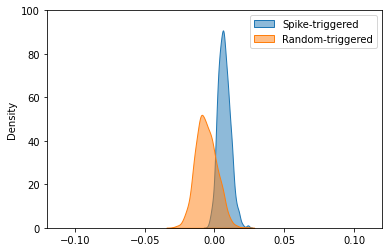

In [307]:
sns.kdeplot(np.hstack(df_ei.iloc[90]['spike_triggered']), fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(np.hstack(df_ei.iloc[90]['random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.legend()
plt.xlim(-0.12,0.12)
plt.ylim(0,100)
plt.savefig(savepath+'example_cell_kde_inh.pdf', dpi=200)
plt.show()

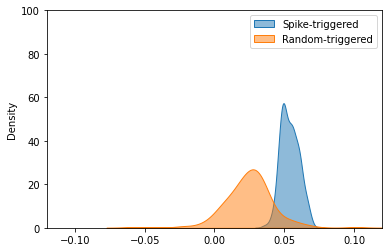

In [309]:
sns.kdeplot(np.hstack(df_ei.iloc[99]['spike_triggered']), fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(np.hstack(df_ei.iloc[99]['random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.legend()
plt.xlim(-0.12,0.12)
plt.ylim(0,100)
plt.savefig(savepath+'example_cell_kde_exc.pdf', dpi=200)
plt.show()

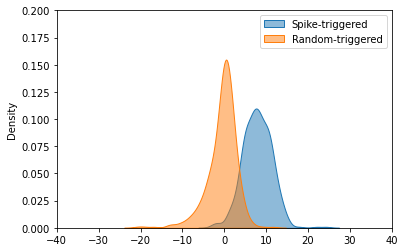

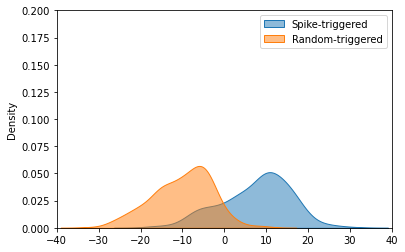

In [312]:
df_ei_exc = df_ei[df_ei.ei_labels==1.0]
df_ei_inh = df_ei[df_ei.ei_labels==0.0]
sns.kdeplot(np.hstack(df_ei_exc['auc_spike_triggered']), fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(np.hstack(df_ei_exc['auc_random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.xlim(-40,40)
plt.ylim(0,0.20)
plt.legend()
plt.savefig(savepath+'all_cells_auc_kde_exc.pdf', dpi=200)
plt.show()

sns.kdeplot(np.hstack(df_ei_inh['auc_spike_triggered']), fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(np.hstack(df_ei_inh['auc_random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.xlim(-40,40)
plt.ylim(0,0.20)
plt.legend()
plt.savefig(savepath+'all_cells_auc_kde_inh.pdf', dpi=200)
plt.show()



In [402]:
acsf_d1,drug_d1 = return_acsf_and_drug(df_ei,cond=['d1'],joint=False,remove_duplicates=True,sample=None)
acsf_d1_exc = acsf_d1[acsf_d1.ei_labels==1.0]
drug_d1_exc = drug_d1[drug_d1.ei_labels==1.0]
print('d1 exc:', len(acsf_d1_exc), len(drug_d1_exc))
acsf_d1_inh = acsf_d1[acsf_d1.ei_labels==0.0]
drug_d1_inh = drug_d1[drug_d1.ei_labels==0.0]
print('d1 inh:', len(acsf_d1_inh), len(drug_d1_inh))

acsf_d2,drug_d2 = return_acsf_and_drug(df_ei,cond=['d2'],joint=False,remove_duplicates=True,sample=None)
acsf_d2_exc = acsf_d2[acsf_d2.ei_labels==1.0]
drug_d2_exc = drug_d2[drug_d2.ei_labels==1.0]
print('d2 exc:', len(acsf_d2_exc), len(drug_d2_exc))

acsf_d2_inh = acsf_d2[acsf_d2.ei_labels==0.0]
drug_d2_inh = drug_d2[drug_d2.ei_labels==0.0]
print('d2 inh:', len(acsf_d2_inh), len(drug_d2_inh))



acsf_m1,drug_m1 = return_acsf_and_drug(df_ei,cond=['m1-ago'],joint=False,remove_duplicates=True,sample=None)
acsf_m1_exc = acsf_m1[acsf_m1.ei_labels==1.0]
drug_m1_exc = drug_m1[drug_m1.ei_labels==1.0]
acsf_m1_inh = acsf_m1[acsf_m1.ei_labels==0.0]
drug_m1_inh = drug_m1[drug_m1.ei_labels==0.0]
print('m1 inh:', len(acsf_m1_inh), len(drug_m1_inh))
print('m1 exc:', len(acsf_m1_exc), len(drug_m1_exc))

d1 exc: 23 23
d1 inh: 14 14
d2 exc: 37 37
d2 inh: 22 22
m1 inh: 21 21
m1 exc: 19 19


In [412]:
diff_mean_d1_drug_inh = drug_d1_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_d1_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_d1_acsf_inh = acsf_d1_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_d1_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_d1_acsf_inh, diff_mean_d1_drug_inh))

diff_mean_d1_drug_exc = drug_d1_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_d1_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_d1_acsf_exc = acsf_d1_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_d1_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_d1_acsf_exc, diff_mean_d1_drug_exc))    

WilcoxonResult(statistic=45.0, pvalue=0.6697998046875)
WilcoxonResult(statistic=80.0, pvalue=0.08020281791687012)


In [411]:
diff_mean_d2_drug_inh = drug_d2_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_d2_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_d2_acsf_inh = acsf_d2_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_d2_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_d2_acsf_inh, diff_mean_d2_drug_inh))

diff_mean_d2_drug_exc = drug_d2_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_d2_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_d2_acsf_exc = acsf_d2_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_d2_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_d2_acsf_exc, diff_mean_d2_drug_exc))    

WilcoxonResult(statistic=122.0, pvalue=0.898735523223877)
WilcoxonResult(statistic=345.0, pvalue=0.928741315510706)


In [410]:
diff_mean_m1_drug_inh = drug_m1_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_m1_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_m1_acsf_inh = acsf_m1_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_m1_inh['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_m1_acsf_inh, diff_mean_m1_drug_inh))

diff_mean_m1_drug_exc = drug_m1_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_m1_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
diff_mean_m1_acsf_exc = acsf_m1_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_m1_exc['mean_random_triggered'].to_numpy(dtype=np.float32)
print(stats.wilcoxon(diff_mean_m1_acsf_exc, diff_mean_m1_drug_exc))    

WilcoxonResult(statistic=86.0, pvalue=0.32045745849609375)
WilcoxonResult(statistic=27.0, pvalue=0.00457763671875)


<ipython-input-417-1867ffbbff4c>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acsf_exc = acsf[df.ei_labels==1.0]
<ipython-input-417-1867ffbbff4c>:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acsf_inh = acsf[df.ei_labels==0.0]


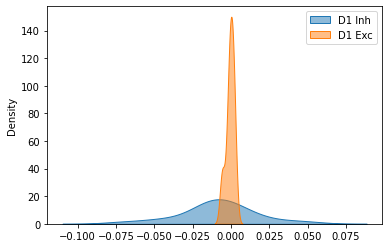

In [417]:
def calculate_score(df,cond):
    acsf,drug = return_acsf_and_drug(df,cond=cond,joint=False,remove_duplicates=True,sample=None)
    acsf_exc = acsf[df.ei_labels==1.0]
    acsf_inh = acsf[df.ei_labels==0.0]
    drug_exc = drug[drug.ei_labels==1.0]
    drug_inh = drug[drug.ei_labels==0.0]
    a_inh =  (drug_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_inh['mean_random_triggered'].to_numpy(dtype=np.float32))    
    b_inh = (acsf_inh['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_inh['mean_random_triggered'].to_numpy(dtype=np.float32))
    score_inh = a_inh- b_inh
    a_exc =  (drug_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-drug_exc['mean_random_triggered'].to_numpy(dtype=np.float32))
    b_exc = (acsf_exc['mean_spike_triggered'].to_numpy(dtype=np.float32)-acsf_exc['mean_random_triggered'].to_numpy(dtype=np.float32))
    score_exc = a_exc- b_exc
    return score_inh,score_exc 

score_inh_d1, score_exc_d1 = calculate_score(df_ei,cond=['d1'])

sns.kdeplot(score_exc_d1, fill=True, alpha=0.5, label='D1 Inh')
sns.kdeplot(score_inh_d1, fill=True, alpha=0.5, label='D1 Exc')
plt.legend()


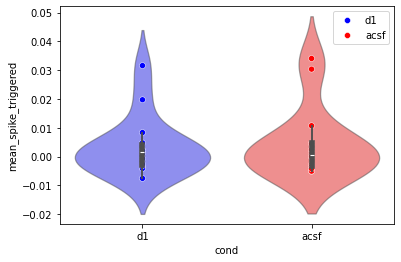

In [ ]:
sns.violinplot(pd.concat([drug_d1_inh,acsf_d1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.5)
sns.scatterplot(pd.concat([drug_d1_inh,acsf_d1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()

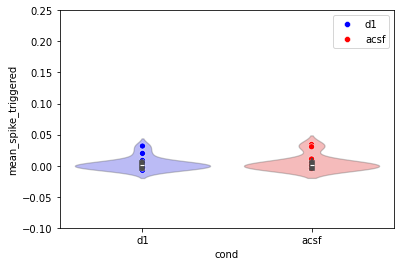

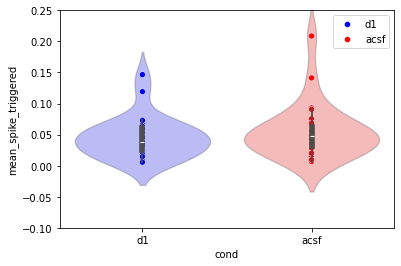

In [467]:
sns.violinplot(pd.concat([drug_d1_inh,acsf_d1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_d1_inh,acsf_d1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)
plt.savefig(savepath+'D1_gain_kde_inh.pdf', dpi=200)
plt.show()

sns.violinplot(pd.concat([drug_d1_exc,acsf_d1_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_d1_exc,acsf_d1_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)
plt.savefig(savepath+'D1_gain_kde_exc.pdf', dpi=200)
plt.show()

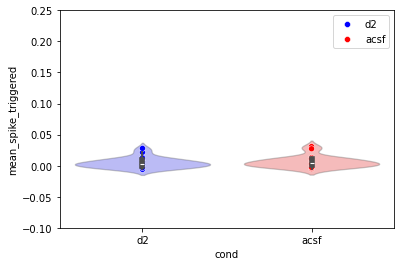

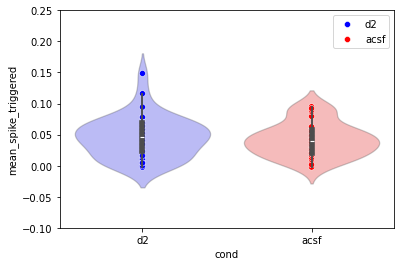

In [463]:
sns.violinplot(pd.concat([drug_d2_inh,acsf_d2_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_d2_inh,acsf_d2_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)
plt.savefig(savepath+'D2_gain_kde_inh.pdf', dpi=200)
plt.show()

sns.violinplot(pd.concat([drug_d2_exc,acsf_d2_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_d2_exc,acsf_d2_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)

plt.savefig(savepath+'D2_gain_kde_exc.pdf', dpi=200)
plt.show()

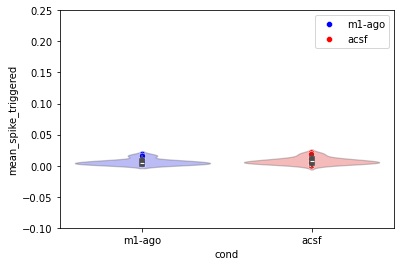

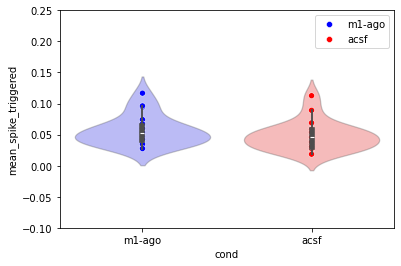

In [464]:
sns.violinplot(pd.concat([drug_m1_inh,acsf_m1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_m1_inh,acsf_m1_inh]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)
plt.savefig(savepath+'M1_gain_kde_inh.pdf', dpi=200)
plt.show()

sns.violinplot(pd.concat([drug_m1_exc,acsf_m1_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'],alpha=0.3)
sns.scatterplot(pd.concat([drug_m1_exc,acsf_m1_exc]),y='mean_spike_triggered',x='cond',hue='cond',palette=['blue','red'])
plt.legend()
plt.ylim(-0.1,0.25)
plt.savefig(savepath+'M1_gain_kde_exc.pdf', dpi=200)
plt.show()

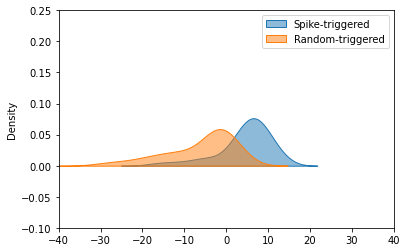

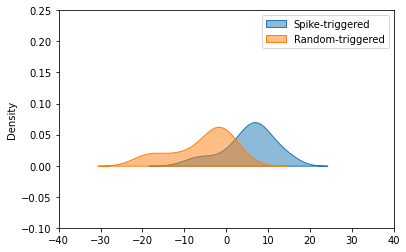

In [465]:
sns.kdeplot(data=np.hstack(acsf_d1['auc_spike_triggered']) ,fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(data=np.hstack(acsf_d1['auc_random_triggered']),fill=True,  alpha=0.5, label='Random-triggered')
plt.xlim(-40,40)
plt.ylim(-0.1,0.25)
plt.legend()
# plt.savefig(savepath+'d1_acsf_auc_kde.pdf', dpi=200)
plt.show()
sns.kdeplot(data=np.hstack(drug_d1['auc_spike_triggered'])  , fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(data=np.hstack(drug_d1['auc_random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.xlim(-40,40)
plt.ylim(-0.1,0.25)
plt.legend()
# plt.savefig(savepath+'d1_drug_auc_kde.pdf', dpi=200)
plt.show()

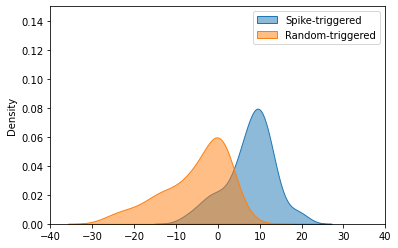

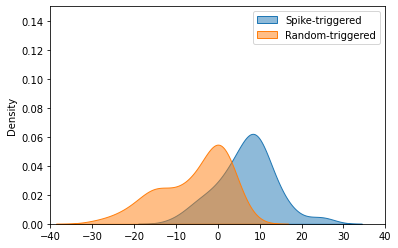

In [398]:
sns.kdeplot(data=np.hstack(acsf_d2['auc_spike_triggered']),  fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(data=np.hstack(acsf_d2['auc_random_triggered']),  fill=True, alpha=0.5, label='Random-triggered')
plt.xlim(-40,40)
plt.ylim(0,0.15)
plt.legend()
# plt.savefig(savepath+'d2_acsf_auc_kde.pdf', dpi=200)
plt.show()
sns.kdeplot(data=np.hstack(drug_d2['auc_spike_triggered'])  , fill=True, alpha=0.5, label='Spike-triggered')
sns.kdeplot(data=np.hstack(drug_d2['auc_random_triggered']), fill=True, alpha=0.5, label='Random-triggered')
plt.legend()
plt.xlim(-40,40)
plt.ylim(0,0.15)
# plt.savefig(savepath+'d2_drug_auc_kde.pdf', dpi=200)
plt.show()

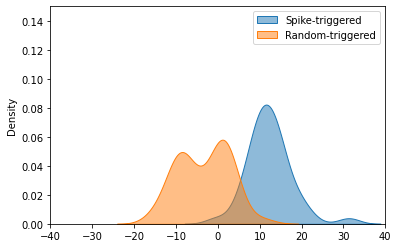

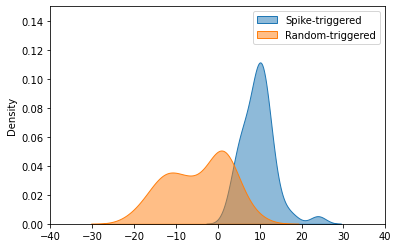

In [399]:
sns.kdeplot(np.hstack(acsf_m1['auc_spike_triggered']),  alpha=0.5,fill=True, label='Spike-triggered')
sns.kdeplot(np.hstack(acsf_m1['auc_random_triggered']),  alpha=0.5, fill=True, label='Random-triggered')
plt.legend()
plt.xlim(-40,40)
plt.ylim(0,0.15)
plt.savefig(savepath+'m1_acsf_auc_kde.pdf', dpi=200)
plt.show()
sns.kdeplot(np.hstack(drug_m1['auc_spike_triggered']),  alpha=0.5, fill=True,    label='Spike-triggered')
sns.kdeplot(np.hstack(drug_m1['auc_random_triggered']),  alpha=0.5, fill=True, label='Random-triggered')
plt.legend()
plt.xlim(-40,40)
plt.ylim(0,0.15)
plt.savefig(savepath+'m1_drug_auc_kde.pdf', dpi=200)
plt.show()

In [ ]:
df_exc = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_mean.csv')
df_inh = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_mean.csv')
df_exc = df_exc[df_exc.columns[1:]]
df_inh = df_inh[df_inh.columns[1:]]

df_exc_std = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_std.csv')
df_inh_std = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_std.csv')
df_inh_std = df_inh_std[df_inh_std.columns[1:]]
df_exc_std = df_exc_std[df_exc_std.columns[1:]]

In [167]:
df_exc[df_exc.Space=='Shared'].dataset

0    ephys
1      bio
2      sta
3      eta
Name: dataset, dtype: object

In [169]:
df_ratio = pd.DataFrame({'dtype':df_exc[df_exc.Space=='Shared'].dataset})
df_ratio['ratio'] =df_exc[df_exc.Space=='Shared']['Variance explained'].to_numpy() / df_exc[df_exc.Space=='Specific']['Variance explained'].to_numpy()  

# Alternate PCA based clustering for robustness

In [95]:
cond = 'm1-ago'

In [96]:
cols_ephys = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr','time_to_first_spike',
             'mean_isi', 'median_isi', 'max_isi', 'min_isi',
             'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
             'mean_width', 'median_width', 'max_width', 'min_width',
             'mean_amplitude', 'median_amplitude', 'min_amplitude']

ephys = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms.pkl")
ephys_with_mi = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms_with_MI.pkl")

# ephys = ephys[~ephys.exp_name.isin(discarded_exps)]
ephys_with_mi = ephys_with_mi[~ephys_with_mi.exp_name.isin(discarded_exps)]


data_ephys_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][ephys.columns[1:]]
data_ephys_FN_acsf = data_ephys_FN_acsf[data_ephys_FN_acsf.trialnr==0]

data_wave_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][['waveform','tau', 'exp_name', 'cond', 'trialnr']]
data_wave_FN_acsf=data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]

ephys_exc = ephys[ephys.ei_labels==1]
ephys_inh = ephys[ephys.ei_labels==0]

df_temp_acsf_exc,df_temp_drug_exc  = return_acsf_and_drug(ephys_exc,cond=[cond],joint=False)
df_temp_acsf_inh,df_temp_drug_inh  = return_acsf_and_drug(ephys_inh,cond=[cond],joint=False)


ephys_acsf_exc = normalize(np.vstack(df_temp_acsf_exc[cols_ephys].to_numpy()))
ephys_drug_exc = normalize(np.vstack(df_temp_drug_exc[cols_ephys].to_numpy()))

ephys_acsf_inh = normalize(np.vstack(df_temp_acsf_inh[cols_ephys].to_numpy()))
ephys_drug_inh = normalize(np.vstack(df_temp_drug_inh[cols_ephys].to_numpy()))

In [97]:
df_new_bio = pd.read_pickle("G:/My Drive/Data For Publication/Data_feature_set/Biophysical_features.pkl")
df_new_bio = df_new_bio[~df_new_bio.exp_name.isin(discarded_exps)]  
# df_bio_exc =df_new_bio[df_new_bio.ei_label==1]
# df_bio_inh = df_new_bio[df_new_bio.ei_label==0]
cols_bio = [ 'gl (nS)','C (nF)','El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)']

# df_bio_exc
bio_exc = df_new_bio[df_new_bio.ei_labels==1]
bio_inh = df_new_bio[df_new_bio.ei_labels==0]


df_acsf_exc,df_drug_exc = return_acsf_and_drug(bio_exc,cond=[cond],joint=False,remove_duplicates=True)

bio_acsf_exc = normalize(np.vstack(df_acsf_exc[cols_bio].to_numpy()),axis=0)
bio_drug_exc = normalize(np.vstack(df_drug_exc[cols_bio].to_numpy()),axis=0)

df_acsf_inh,df_drug_inh = return_acsf_and_drug(bio_inh,cond=[cond],joint=False,remove_duplicates=True)

bio_acsf_inh = normalize(np.vstack(df_acsf_inh[cols_bio].to_numpy()),axis=0)
bio_drug_inh = normalize(np.vstack(df_drug_inh[cols_bio].to_numpy()),axis=0)




eta_exc = df_new_bio[df_new_bio.ei_labels==1]
eta_inh = df_new_bio[df_new_bio.ei_labels==0]


df_acsf_exc,df_drug_exc = return_acsf_and_drug(eta_exc,cond=[cond],joint=False,remove_duplicates=True)

eta_acsf_exc = normalize(np.vstack(df_acsf_exc['eta'].to_numpy()),axis=0)
eta_drug_exc = normalize(np.vstack(df_drug_exc['eta'].to_numpy()),axis=0)

df_acsf_inh,df_drug_inh = return_acsf_and_drug(eta_inh,cond=[cond],joint=False,remove_duplicates=True)

eta_acsf_inh = normalize(np.vstack(df_acsf_inh['eta'].to_numpy()),axis=0)
eta_drug_inh = normalize(np.vstack(df_drug_inh['eta'].to_numpy()),axis=0)




In [98]:
df_sta = pd.read_pickle("G:/My Drive/Data For Publication/Data_feature_set/Spike_triggered_average.pkl")
# df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_normed_input.pkl')
# df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_shifted.pkl')


# df_sta.trial = df_sta.trial.apply(int)
df_sta = df_sta[~df_sta.exp_name.isin(discarded_exps)]
# df_sta_acsf = df_sta[df_sta.cond.isin(['acsf','acsf_bic'])]

# df_sta_acsf = df_sta_acsf[df_sta_acsf.exp_name.isin(set(data_wave_FN_acsf.exp_name))]
# df_sta_acsf = df_sta_acsf[df_sta_acsf.trial==0]
df_sta_exc = df_sta[df_sta.ei_label==1]
df_sta_inh = df_sta[df_sta.ei_label==0]
df_acsf_exc,df_drug_exc = return_acsf_and_drug(df_sta_exc,cond=[cond],joint=False,remove_duplicates=True)

sta_acsf_exc = normalize(np.vstack(df_acsf_exc['sta'].to_numpy()),axis=0)
sta_drug_exc = normalize(np.vstack(df_drug_exc['sta'].to_numpy()),axis=0)

df_acsf_inh,df_drug_inh = return_acsf_and_drug(df_sta_inh,cond=[cond],joint=False,remove_duplicates=True)

sta_acsf_inh = normalize(np.vstack(df_acsf_inh['sta'].to_numpy()),axis=0)
sta_drug_inh = normalize(np.vstack(df_drug_inh['sta'].to_numpy()),axis=0)



In [99]:
set(df_sta.exp_name)

{'NC_101017_E1',
 'NC_101017_E2',
 'NC_101017_E3',
 'NC_101017_E4',
 'NC_101017_E5',
 'NC_101017_E6',
 'NC_101117_E1',
 'NC_101117_E2',
 'NC_101117_E3',
 'NC_111017_E1',
 'NC_111017_E2',
 'NC_111017_E3',
 'NC_111017_E4',
 'NC_111017_E5',
 'NC_111217_E1',
 'NC_111217_E2',
 'NC_111217_E3',
 'NC_11717_E1',
 'NC_11717_E2',
 'NC_11717_E4',
 'NC_11817_E2',
 'NC_11817_E4',
 'NC_11817_E5',
 'NC_11817_E6',
 'NC_121017_E10',
 'NC_121017_E3',
 'NC_121017_E5',
 'NC_121017_E6',
 'NC_121017_E7',
 'NC_121017_E8',
 'NC_121017_E9',
 'NC_121217_E1',
 'NC_121217_E3',
 'NC_12717_E1',
 'NC_12717_E2',
 'NC_131217_E1',
 'NC_131217_E2',
 'NC_131217_E3',
 'NC_131217_E4',
 'NC_13717_E3',
 'NC_13717_E4',
 'NC_13917_E2',
 'NC_141217_E1',
 'NC_141217_E2',
 'NC_14717_E3',
 'NC_14717_E4',
 'NC_14717_E5',
 'NC_14817_E2',
 'NC_14817_E6',
 'NC_14817_E7',
 'NC_14817_E9',
 'NC_14917_E1',
 'NC_15617_E1',
 'NC_15817_E1',
 'NC_15817_E2',
 'NC_15817_E3',
 'NC_15817_E4',
 'NC_15817_E5',
 'NC_15817_E6',
 'NC_15817_E7',
 'NC_16

In [79]:
from sklearn.datasets import load_digits
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import spectral_embedding

import igraph as ig
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import adjusted_mutual_info_score
def pca_louvain_pipeline(data):
    # 1. Linear Dimensionality Reduction via PCA
    # Reducing from 10,000 down to 5 stable components to strip high-dimensional noise
    pca = PCA(n_components=5, random_state=42)
    pca_space = pca.fit_transform(data) 

    # 2. Build a neighborhood graph on the stable PCA space
    # This is where the non-linear manifold tracing begins
    knn_matrix = kneighbors_graph(pca_space, n_neighbors=5, metric='euclidean', mode='connectivity')

    # 3. Convert to igraph for Louvain
    sources, targets = knn_matrix.nonzero()
    g_pca = ig.Graph(directed=False)
    g_pca.add_vertices(pca_space.shape[0])
    g_pca.add_edges(list(zip(sources, targets)))

    # 4. Run Louvain (completely unsupervised cluster discovery)
    pca_louvain_partition = g_pca.community_multilevel()
    pca_louvain_labels = np.array(pca_louvain_partition.membership)
    return pca_louvain_labels
    # 5. Calculate AMI against your original UMAP-graph results
    # ami_score = adjusted_mutual_info_score(umap_graph_louvain_labels, pca_louvain_labels)
    # print(f"AMI between UMAP-graph and PCA-graph pipelines: {ami_score:.4f}")

In [80]:
exc_ephys_labels_acsf = pca_louvain_pipeline(ephys_acsf_exc)
exc_ephys_labels_drug = pca_louvain_pipeline(ephys_drug_exc)
ephys_labels_exc = adjusted_mutual_info_score(exc_ephys_labels_acsf, exc_ephys_labels_drug)

inh_ephys_labels_acsf = pca_louvain_pipeline(ephys_acsf_inh)
inh_ephys_labels_drug = pca_louvain_pipeline(ephys_drug_inh)
ephys_labels_inh = adjusted_mutual_info_score(inh_ephys_labels_acsf, inh_ephys_labels_drug)



In [81]:
exc_sta_labels_acsf = pca_louvain_pipeline(sta_acsf_exc)
exc_sta_labels_drug = pca_louvain_pipeline(sta_drug_exc)
sta_labels_exc = adjusted_mutual_info_score(exc_sta_labels_acsf, exc_sta_labels_drug)

inh_sta_labels_acsf = pca_louvain_pipeline(sta_acsf_inh)
inh_sta_labels_drug = pca_louvain_pipeline(sta_drug_inh)
sta_labels_inh = adjusted_mutual_info_score(inh_sta_labels_acsf, inh_sta_labels_drug)



In [82]:
exc_bio_labels_acsf = pca_louvain_pipeline(bio_acsf_exc)
exc_bio_labels_drug = pca_louvain_pipeline(bio_drug_exc)
bio_labels_exc = adjusted_mutual_info_score(exc_bio_labels_acsf, exc_bio_labels_drug)

inh_bio_labels_acsf = pca_louvain_pipeline(bio_acsf_inh)
inh_bio_labels_drug = pca_louvain_pipeline(bio_drug_inh)
bio_labels_inh = adjusted_mutual_info_score(inh_bio_labels_acsf, inh_bio_labels_drug)


In [83]:
exc_eta_labels_acsf = pca_louvain_pipeline(eta_acsf_exc)
exc_eta_labels_drug = pca_louvain_pipeline(eta_drug_exc)
eta_labels_exc = adjusted_mutual_info_score(exc_eta_labels_acsf, exc_eta_labels_drug)

inh_eta_labels_acsf = pca_louvain_pipeline(eta_acsf_inh)
inh_eta_labels_drug = pca_louvain_pipeline(eta_drug_inh)
eta_labels_inh = adjusted_mutual_info_score(inh_eta_labels_acsf, inh_eta_labels_drug)


In [84]:
AMI_df = pd.DataFrame({'Dataset':['AP','STA','PB','AC'],
                       'Excitatory': [ephys_labels_exc, sta_labels_exc, bio_labels_exc, eta_labels_exc],
                       'Inhibitory': [ephys_labels_inh, sta_labels_inh, bio_labels_inh, eta_labels_inh]})


In [85]:
AMI_df

,Dataset,Excitatory,Inhibitory
0,AP,0.028329,0.357968
1,STA,0.396671,0.339892
2,PB,0.134543,0.210496
3,AC,0.040089,0.148116


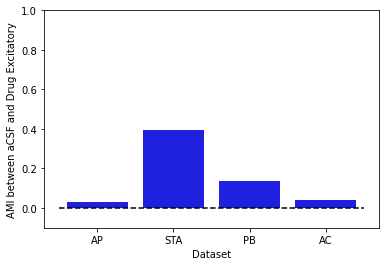

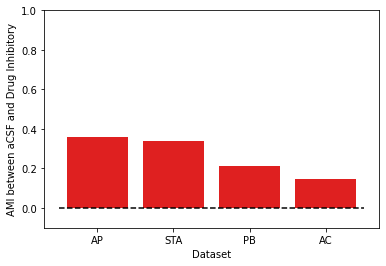

In [86]:
sns.barplot(AMI_df,x='Dataset',y='Excitatory',  color='blue')
plt.hlines(0.0, -0.5, 3.5, color='black', linestyle='--')
plt.ylim(-0.1,1)
plt.ylabel('AMI between aCSF and Drug Excitatory')
plt.savefig(savepath+f'{cond}_exc_AMI.pdf', dpi=200)
plt.show()
sns.barplot(AMI_df,x='Dataset',y='Inhibitory',  color='red')
plt.hlines(0.0, -0.5, 3.5, color='black', linestyle='--')
plt.ylim(-0.1,1)
plt.ylabel('AMI between aCSF and Drug Inhibitory')
plt.savefig(savepath+f'{cond}_inh_AMI.pdf', dpi=200)
plt.show()

## PCCA revision

In [7]:

temp_exc_all_mean = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_mean.csv')
temp_inh_all_mean = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_mean.csv')


temp_exc_all_std = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_std.csv')
temp_inh_all_std = pd.read_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_std.csv')

In [65]:
temp_inh_all_mean

,Unnamed: 0,dataset,Space,Variance explained
0,0,ephys,Shared,0.333100
1,1,bio,Shared,0.334016
2,3,eta,Shared,0.269764
3,2,sta,Shared,0.236595
4,4,ephys,Specific,0.149273
5,5,bio,Specific,0.131228
6,7,eta,Specific,0.227059
7,6,sta,Specific,0.551458
8,8,ephys,Residual,0.517628
9,9,bio,Residual,0.534756


In [9]:
temp_exc_all_mean = temp_exc_all_mean.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_inh_all_mean = temp_inh_all_mean.reindex([0,1,3,2,4,5,7,6,8,9,11,10])

temp_inh_all_std = temp_inh_all_std.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_exc_all_std = temp_exc_all_std.reindex([0,1,3,2,4,5,7,6,8,9,11,10])


In [66]:
def plot_bootstraped_data(data,savepath = 'G:/My Drive/Data For Publication/paper2/part1/',cond=None,save=False,ei_type='exc'):
    fig,ax = plt.subplots(figsize=(7, 5))       
    sns.histplot(data, y='dataset', hue='Space',hue_order= ['Residual','Specific','Shared'], weights='Variance explained',
                multiple='stack', palette='icefire',ax =ax)
    ax.set(title='Percent variance explained', xlabel=None, ylabel=None)
    ax.set_xlim(0, 1)
    ax.tick_params(left=False)
    ax.set_yticklabels=['ephys','bio','eta','sta']
    if save:
        plt.savefig(savepath+cond+'_'+ei_type+'.pdf',dpi=200)
    else:
        plt.savefig('G:/My Drive/Data For Publication/paper2/part1/'+cond+'_'+ei_type+'.pdf',dpi=200)
    plt.show()

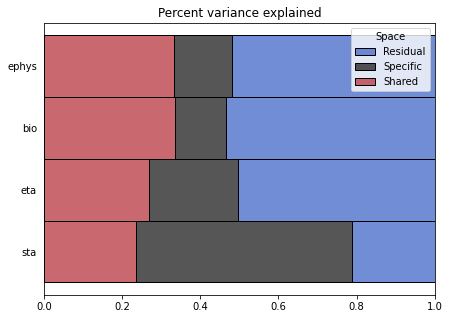

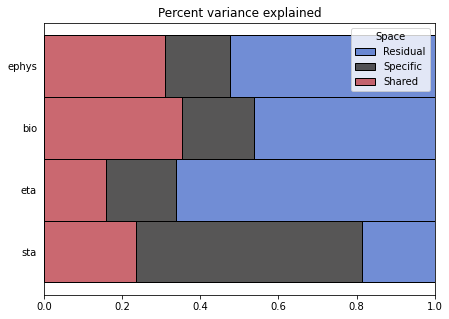

In [70]:
plot_bootstraped_data(temp_inh_all_mean,cond='acsf',ei_type='exc',save=False)
plot_bootstraped_data(temp_exc_all_mean,cond='acsf',ei_type='exc',save=False)

In [16]:
temp_inh_all = temp_inh_all_mean.copy()
temp_exc_all = temp_exc_all_mean.copy()

temp_inh_all['std'] = temp_inh_all_std['Variance explained']
temp_exc_all['std'] = temp_exc_all_std['Variance explained']

In [61]:
temp_inh_all

,Unnamed: 0,dataset,Space,Variance explained,std
0,0,ephys,Shared,0.333100,0.120733
1,1,bio,Shared,0.334016,0.148031
2,3,eta,Shared,0.269764,0.172281
3,2,sta,Shared,0.236595,0.146504
4,4,ephys,Specific,0.149273,0.095664
5,5,bio,Specific,0.131228,0.104673
6,7,eta,Specific,0.227059,0.258563
7,6,sta,Specific,0.551458,0.165534
8,8,ephys,Residual,0.517628,0.102972
9,9,bio,Residual,0.534756,0.150644


In [32]:
error = [temp_inh_all['Variance explained'].to_numpy() - temp_inh_all['std'].to_numpy(),
         temp_exc_all['Variance explained'].to_numpy() - temp_exc_all['std'].to_numpy()]

In [49]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ['ephys', 'bio', 'eta', 'sta']
spaces   = ['Shared', 'Specific', 'Residual']

# pivot to 2D arrays: shape (4 datasets, 3 spaces)
means_exc = temp_exc_all.pivot(index='dataset', columns='Space', values='Variance explained').loc[datasets, spaces].to_numpy()
errs_exc  = temp_exc_all.pivot(index='dataset', columns='Space', values='std').loc[datasets, spaces].to_numpy()
means_inh = temp_inh_all.pivot(index='dataset', columns='Space', values='Variance explained').loc[datasets, spaces].to_numpy()
errs_inh  = temp_inh_all.pivot(index='dataset', columns='Space', values='std').loc[datasets, spaces].to_numpy()

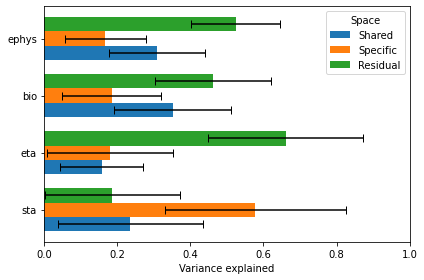

In [72]:
import numpy as np
import matplotlib.pyplot as plt

datasets = [ 'sta',  'eta',  'bio','ephys']
spaces   = ['Shared', 'Specific', 'Residual']

means = temp_exc_all.pivot(index='dataset', columns='Space', values='Variance explained')\
          .loc[datasets, spaces].to_numpy()
errs  = temp_exc_all.pivot(index='dataset', columns='Space', values='std')\
          .loc[datasets, spaces].to_numpy()
    
y = np.arange(len(datasets))   # 0..3 for horizontal axis positions
height = 0.25                  # bar thickness

fig, ax = plt.subplots()

for j, space in enumerate(spaces):
    offset = (j - 1) * height  # center the 3 bars around each y position
    ax.barh(
        y + offset,            # y positions
        means[:, j],           # bar lengths (x)
        height,                # bar thickness
        xerr=errs[:, j],       # horizontal error bars
        label=space,
        capsize=4,
    )

ax.set_yticks(y)
ax.set_yticklabels(datasets)
ax.set_xlabel('Variance explained')
ax.legend(title='Space')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(savepath+'exc_variance_explained_with error_bars.pdf', dpi=200)
plt.show()

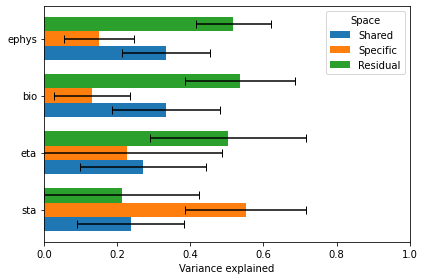

In [71]:
import numpy as np
import matplotlib.pyplot as plt

datasets = [ 'sta',  'eta',  'bio','ephys']
spaces   = ['Shared', 'Specific', 'Residual']

means = temp_inh_all.pivot(index='dataset', columns='Space', values='Variance explained')\
          .loc[datasets, spaces].to_numpy()
errs  = temp_inh_all.pivot(index='dataset', columns='Space', values='std')\
          .loc[datasets, spaces].to_numpy()
    
y = np.arange(len(datasets))   # 0..3 for horizontal axis positions
height = 0.25                  # bar thickness

fig, ax = plt.subplots()

for j, space in enumerate(spaces):
    offset = (j - 1) * height  # center the 3 bars around each y position
    ax.barh(
        y + offset,            # y positions
        means[:, j],           # bar lengths (x)
        height,                # bar thickness
        xerr=errs[:, j],       # horizontal error bars
        label=space,
        capsize=4,
    )

ax.set_yticks(y)
ax.set_yticklabels(datasets)
ax.set_xlabel('Variance explained')
ax.legend(title='Space')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(savepath+'inh_variance_explained_with error_bars.pdf', dpi=200)

plt.show()